<a href="https://colab.research.google.com/github/young0206/computer_vision/blob/main/06.%EC%9E%84%EB%B2%A0%EB%94%94%EB%93%9C/01.delf/notebook_tf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mounting Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cd /content/drive/MyDrive/33project/06.임베디드/01.delf/delf_tf

/content/drive/MyDrive/33project/06.임베디드/01.delf/delf_tf


#Installing Libraries
###Not neccessary

In [ ]:
# !bash install_delf.sh
# !pip3 install tensorflow-gpu

#Importing Libraries

In [4]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

print("protobuf Python implementation 설정 완료")

protobuf Python implementation 설정 완료


In [6]:
import sys

from absl import app
import ma inline
import matplotlib.pyplot as plt

import numpy as np
from scipy import spatial
from skimage import featurtplotlib
# Needed before pyplot import for matplotlib to work properly.
matplotlib.use('Agg')
import matplotlib.image as mpimg  # pylint: disable=g-import-not-at-top
%matplotlibe
from skimage import measure
from skimage import transform
import sys


from delf.protos import feature_io

import tensorflow as tf

from delf.python.training.model import resnet50 as resnet

layers = tf.keras.layers
reg = tf.keras.regularizers


import os
import time

from absl import app
from absl import flags
from absl import logging
import tensorflow as tf
import tensorflow_probability as tfp

# Placeholder for internal import. Do not remove this line.
from delf.python.datasets.google_landmarks_dataset import googlelandmarks as gld
from delf.python.training.model import delf_model
from delf.python.training.model import delg_model

#Defining Variables

In [7]:
debug=False
logdir='result_log'
train_file_pattern='gldv2_dataset/tfrecord/train*'
dataset_path='gldv2_dataset'
validation_file_pattern= 'gldv2_dataset/tfrecord/validation*'
image_1_path='data/oxford5k_images/hertford_000056.jpg'
image_2_path='data/oxford5k_images/oxford_000317.jpg'
features_1_path='data/oxford5k_features/hertford_000056.delf'
features_2_path='data/oxford5k_features/oxford_000317.delf'
output_image='Result.png'
_DISTANCE_THRESHOLD = 0.8


dataset_version= 'gld_v2_clean'
_DECAY = 0.0001
seed=0
initial_lr=0.01
batch_size=32
max_iters=500000
block3_strides=True
use_augmentation=True

imagenet_checkpoint=None

attention_loss_weight=1.0

delg_global_features=False

delg_gem_power=3.0
delg_global_features=True

delg_embedding_layer_dim= 2048

delg_scale_factor_init=45.25

delg_arcface_margin=0.1

image_size=321
use_autoencoder=True

reconstruction_loss_weight=10.0

autoencoder_dimensions=128

local_feature_map_channels=1024

##Downloading pretrained Model

In [8]:
# From tensorflow/models/research/delf/delf/python/examples/

import os

# 현재 DELF 프로젝트 경로
project_path = "/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch"
pretrained_model = os.path.join(project_path, "pretrained_model")

# 프로젝트 폴더로 이동
%cd /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch


# ==========================================
# Pretrained model
# ==========================================

if os.path.exists(pretrained_model) is False:
    print("Downloading pretrained weights")
    os.makedirs(pretrained_model, exist_ok=True)

    %cd /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/pretrained_model

    !gdown "https://drive.google.com/u/0/uc?id=1dbdaDyVeIb53iGh4Uk5kA4in9-uURoLM&export=download"

    !tar -xvf pretrained_model.tar

    %cd /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch

else:
    print("Pre_trained Model Already Downloaded")


# ==========================================
# DELF parameters
# ==========================================

os.makedirs("parameters", exist_ok=True)

%cd /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/parameters

!wget -nc http://storage.googleapis.com/delf/delf_gld_20190411.tar.gz

!tar -xvzf delf_gld_20190411.tar.gz

%cd /content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch

/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch
Pre_trained Model Already Downloaded
/content/drive/MyDrive/33project/06.임베디드/01.delf/DeLF-pytorch/parameters
--2026-10-01 03:16:36--  http://storage.googleapis.com/delf/delf_gld_20190411.tar.gz
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.43.207, 108.177.98.207, 74.125.135.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.43.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41579253 (40M) [application/octet-stream]
Saving to: ‘delf_gld_20190411.tar.gz’

delf_gld_20190411.t 100%[===================>]  39.65M  97.6MB/s    in 0.4s    

2026-10-01 03:16:36 (97.6 MB/s) - ‘delf_gld_20190411.tar.gz’ saved [41579253/41579253]

delf_gld_20190411/
delf_gld_20190411/model/
delf_gld_20190411/model/saved_model.pb
delf_gld_20190411/model/variables/
delf_gld_20190411/model/variables/variables.data-00000-of-00001
delf_gld_20190411/model/variables/variables.inde

#Defining Model

In [9]:
class AttentionModel(tf.keras.Model):
  """Instantiates attention model.

  Uses two [kernel_size x kernel_size] convolutions and softplus as activation
  to compute an attention map with the same resolution as the featuremap.
  Features l2-normalized and aggregated using attention probabilites as weights.
  The features (targets) to be aggregated can be the input featuremap, or a
  different one with the same resolution.
  """

  def __init__(self, kernel_size=1, decay=_DECAY, name='attention'):
    """Initialization of attention model.

    Args:
      kernel_size: int, kernel size of convolutions.
      decay: float, decay for l2 regularization of kernel weights.
      name: str, name to identify model.
    """
    super(AttentionModel, self).__init__(name=name)

    # First convolutional layer (called with relu activation).
    self.conv1 = layers.Conv2D(
        512,
        kernel_size,
        kernel_regularizer=reg.l2(decay),
        padding='same',
        name='attn_conv1')
    self.bn_conv1 = layers.BatchNormalization(axis=3, name='bn_conv1')

    # Second convolutional layer, with softplus activation.
    self.conv2 = layers.Conv2D(
        1,
        kernel_size,
        kernel_regularizer=reg.l2(decay),
        padding='same',
        name='attn_conv2')
    self.activation_layer = layers.Activation('softplus')

  def call(self, inputs, targets=None, training=True):
    x = self.conv1(inputs)
    x = self.bn_conv1(x, training=training)
    x = tf.nn.relu(x)

    score = self.conv2(x)
    prob = self.activation_layer(score)

    # Aggregate inputs if targets is None.
    if targets is None:
      targets = inputs

    # L2-normalize the featuremap before pooling.
    targets = tf.nn.l2_normalize(targets, axis=-1)
    feat = tf.reduce_mean(tf.multiply(targets, prob), [1, 2], keepdims=False)

    return feat, prob, score


class AutoencoderModel(tf.keras.Model):
  """Instantiates the Keras Autoencoder model."""

  def __init__(self, reduced_dimension, expand_dimension, kernel_size=1,
               name='autoencoder'):
    """Initialization of Autoencoder model.

    Args:
      reduced_dimension: int, the output dimension of the autoencoder layer.
      expand_dimension: int, the input dimension of the autoencoder layer.
      kernel_size: int or tuple, height and width of the 2D convolution window.
      name: str, name to identify model.
    """
    super(AutoencoderModel, self).__init__(name=name)
    self.conv1 = layers.Conv2D(
        reduced_dimension,
        kernel_size,
        padding='same',
        name='autoenc_conv1')
    self.conv2 = layers.Conv2D(
        expand_dimension,
        kernel_size,
        activation=tf.keras.activations.relu,
        padding='same',
        name='autoenc_conv2')

  def call(self, inputs):
    dim_reduced_features = self.conv1(inputs)
    dim_expanded_features = self.conv2(dim_reduced_features)
    return dim_expanded_features, dim_reduced_features


class Delf(tf.keras.Model):
  """Instantiates Keras DELF modeldelf_tf using ResNet50 as backbone.

  This class implements the [DELF](https://arxiv.org/abs/1612.06321) model for
  extracting local features from images. The backbone is a ResNet50 network
  that extracts featuremaps from both conv_4 and conv_5 layers. Activations
  from conv_4 are used to compute an attention map of the same resolution.
  """

  def __init__(self,
               block3_strides=True,
               name='DELF',
               pooling='avg',
               gem_power=3.0,
               embedding_layer=False,
               embedding_layer_dim=2048,
               use_dim_reduction=False,
               reduced_dimension=128,
               dim_expand_channels=1024):
    """Initialization of DELF model.

    Args:
      block3_strides: bool, whether to add strides to the output of block3.
      name: str, name to identify model.
      pooling: str, pooling mode for global feature extraction; possible values
        are 'None', 'avg', 'max', 'gem.'
      gem_power: float, GeM power for GeM pooling. Only used if pooling ==
        'gem'.
      embedding_layer: bool, whether to create an embedding layer (FC whitening
        layer).
      embedding_layer_dim: int, size of the embedding layer.
      use_dim_reduction: Whether to integrate dimensionality reduction layers.
        If True, extra layers are added to reduce the dimensionality of the
        extracted features.
      reduced_dimension: int, only used if use_dim_reduction is True. The output
        dimension of the autoencoder layer.
      dim_expand_channels: int, only used if use_dim_reduction is True. The
        number of channels of the backbone block used. Default value 1024 is the
        number of channels of backbone block 'block3'.
    """
    super(Delf, self).__init__(name=name)

    # Backbone using Keras ResNet50.
    self.backbone = resnet.ResNet50(
        'channels_last',
        name='backbone',
        include_top=False,
        pooling=pooling,
        block3_strides=block3_strides,
        average_pooling=False,
        gem_power=gem_power,
        embedding_layer=embedding_layer,
        embedding_layer_dim=embedding_layer_dim)

    # Attention model.
    self.attention = AttentionModel(name='attention')

    # Autoencoder model.
    self._use_dim_reduction = use_dim_reduction
    if self._use_dim_reduction:
      self.autoencoder = AutoencoderModel(reduced_dimension,
                                          dim_expand_channels,
                                          name='autoencoder')

  def init_classifiers(self, num_classes, desc_classification=None):
    """Define classifiers for training backbone and attention models."""
    self.num_classes = num_classes
    if desc_classification is None:
      self.desc_classification = layers.Dense(
          num_classes, activation=None, kernel_regularizer=None, name='desc_fc')
    else:
      self.desc_classification = desc_classification
    self.attn_classification = layers.Dense(
        num_classes, activation=None, kernel_regularizer=None, name='att_fc')

  def global_and_local_forward_pass(self, images, training=True):
    """Run a forward to calculate global descriptor and attention prelogits.

    Args:
      images: Tensor containing the dataset on which to run the forward pass.
      training: Indicator of wether the forward pass is running in training mode
        or not.

    Returns:
      Global descriptor prelogits, attention prelogits, attention scores,
        backbone weights.
    """
    backbone_blocks = {}
    desc_prelogits = self.backbone.build_call(
        images, intermediates_dict=backbone_blocks, training=training)
    # Prevent gradients from propagating into the backbone. See DELG paper:
    # https://arxiv.org/abs/2001.05027.
    block3 = backbone_blocks['block3']  # pytype: disable=key-error
    block3 = tf.stop_gradient(block3)
    if self._use_dim_reduction:
      (dim_expanded_features, dim_reduced_features) = self.autoencoder(block3)
      attn_prelogits, attn_scores, _ = self.attention(
          block3,
          targets=dim_expanded_features,
          training=training)
    else:
      attn_prelogits, attn_scores, _ = self.attention(block3, training=training)
      dim_expanded_features = None
      dim_reduced_features = None
    return (desc_prelogits, attn_prelogits, attn_scores, backbone_blocks,
            dim_expanded_features, dim_reduced_features)

  def build_call(self, input_image, training=True):
    (global_feature, _, attn_scores, backbone_blocks, _,
     dim_reduced_features) = self.global_and_local_forward_pass(input_image,
                                                                training)
    if self._use_dim_reduction:
      features = dim_reduced_features
    else:
      features = backbone_blocks['block3']  # pytype: disable=key-error
    return global_feature, attn_scores, features

  def call(self, input_image, training=True):
    _, probs, features = self.build_call(input_image, training=training)
    return probs, features


#Training

In [11]:
cd /content/drive/MyDrive/33project/06.임베디드/01.delf/delf_tf/delf/python/training

/content/drive/MyDrive/33project/06.임베디드/01.delf/delf_tf/delf/python/training


#Downloading Dataset
###Google Landmarks Dataset is 100+GB dataset, So downloading a part of it for sample training

In [13]:
if os.path.exists(dataset_path) is False:
    print("Downloading Dataset")

    !bash "/content/drive/MyDrive/33project/06.임베디드/01.delf/delf_tf/delf/python/training/download_dataset.sh" 1 1 1

    os.makedirs("gldv2_dataset/tfrecord", exist_ok=True)
else:
    print("Dataset already Downloaded")

Creating folder gldv2_dataset.
Successfully created folder gldv2_dataset.
Creating folder gldv2_dataset/train.
Successfully created folder gldv2_dataset/train.
Checking MD5 checksum of file gldv2_dataset/train/images_000.tar against gldv2_dataset/train/md5.images_000.txt
Check passed.
Extracting file gldv2_dataset/train/images_000.tar to folder gldv2_dataset/train
Creating folder gldv2_dataset/test.
Successfully created folder gldv2_dataset/test.
Checking MD5 checksum of file gldv2_dataset/test/images_000.tar against gldv2_dataset/test/md5.images_000.txt
Check passed.
Extracting file gldv2_dataset/test/images_000.tar to folder gldv2_dataset/test
Creating folder gldv2_dataset/index.
Successfully created folder gldv2_dataset/index.
Checking MD5 checksum of file gldv2_dataset/index/images_000.tar against gldv2_dataset/index/md5.images_000.txt
Check passed.
Extracting file gldv2_dataset/index/images_000.tar to folder gldv2_dataset/index


#Converting Dataset to TFrecord for Training

In [15]:
from pathlib import Path

file_path = Path(
    "/content/drive/MyDrive/33project/06.임베디드/01.delf/"
    "delf_tf/delf/python/training/build_image_dataset.py"
)

code = file_path.read_text()

code = code.replace("dtype=np.int)", "dtype=int)")

file_path.write_text(code)

print("np.int → int 수정 완료")

np.int → int 수정 완료


In [16]:
!python3 build_image_dataset.py \
--output_directory=gldv2_dataset/tfrecord/ \
--num_shards=128 \
--train_csv_path=gldv2_dataset/train/train.csv \
--train_directory=gldv2_dataset/train/*/*/*/ \
--generate_train_validation_splits \

Processing shard  0  and writing file  gldv2_dataset/tfrecord/validation-00000-of-00128
2026-10-01 03:25:44.934671: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1790825144.936181    4473 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Processing shard  1  and writing file  gldv2_dataset/tfrecord/validation-00001-of-00128
Processing shard  2  and writing file  gldv2_dataset/tfrecord/validation-00002-of-00128
Processing shard  3  and writing file  gldv2_dataset/tfrecord/validation-00003-of-00128
Processing shard  4  and writing file  gldv2_dataset/tfrecord/validation-00004-of-00128
Processing shard  5  and writing file  gldv2_dataset/tfrecord/validation-00005-of-00128
Processing shard  6  and writing fi

#Training Script
###Requires GPU

In [18]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function



def _record_accuracy(metric, logits, labels):
  """Record accuracy given predicted logits and ground-truth labels."""
  softmax_probabilities = tf.keras.layers.Softmax()(logits)
  metric.update_state(labels, softmax_probabilities)


def _attention_summaries(scores, global_step):
  """Record statistics of the attention score."""
  tf.summary.image(
      'batch_attention',
      scores / tf.reduce_max(scores + 1e-3),
      step=global_step)
  tf.summary.scalar('attention/max', tf.reduce_max(scores), step=global_step)
  tf.summary.scalar('attention/min', tf.reduce_min(scores), step=global_step)
  tf.summary.scalar('attention/mean', tf.reduce_mean(scores), step=global_step)
  tf.summary.scalar(
      'attention/percent_25',
      tfp.stats.percentile(scores, 25.0),
      step=global_step)
  tf.summary.scalar(
      'attention/percent_50',
      tfp.stats.percentile(scores, 50.0),
      step=global_step)
  tf.summary.scalar(
      'attention/percent_75',
      tfp.stats.percentile(scores, 75.0),
      step=global_step)


def create_model(num_classes):
  """Define DELF model, and initialize classifiers."""
  if delg_global_features:
    model = delg_model.Delg(
        block3_strides=block3_strides,
        name='DELG',
        gem_power=delg_gem_power,
        embedding_layer_dim=delg_embedding_layer_dim,
        scale_factor_init=delg_scale_factor_init,
        arcface_margin=delg_arcface_margin,
        use_dim_reduction=use_autoencoder,
        reduced_dimension=autoencoder_dimensions,
        dim_expand_channels=local_feature_map_channels)
  else:
    model = delf_model.Delf(
        block3_strides=block3_strides,
        name='DELF',
        use_dim_reduction=use_autoencoder,
        reduced_dimension=autoencoder_dimensions,
        dim_expand_channels=local_feature_map_channels)
  model.init_classifiers(num_classes)
  return model


def _learning_rate_schedule(global_step_value, max_iters, initial_lr):
  """Calculates learning_rate with linear decay.

  Args:
    global_step_value: int, global step.
    max_iters: int, maximum iterations.
    initial_lr: float, initial learning rate.

  Returns:
    lr: float, learning rate.
  """
  lr = initial_lr * (1.0 - global_step_value / max_iters)
  return lr


# def main(initial_lr,max_iters,image_size):

print('Running training script with\n')
print('logdir= %s', logdir)
print('initial_lr= %f', initial_lr)
print('block3_strides= %s', str(block3_strides))

# ------------------------------------------------------------
# Create the strategy.
strategy = tf.distribute.MirroredStrategy()
print('Number of devices: %d', strategy.num_replicas_in_sync)
if debug:
  print('Number of devices:', strategy.num_replicas_in_sync)

max_iters = max_iters
global_batch_size = batch_size
image_size = image_size
num_eval_batches = int(50000 / global_batch_size)
report_interval = 100
eval_interval = 1000
save_interval = 1000

initial_lr = initial_lr

clip_val = tf.constant(10.0)

if debug:
  tf.config.run_functions_eagerly(True)
  global_batch_size = 4
  max_iters = 100
  num_eval_batches = 1
  save_interval = 1
  report_interval = 10

# Determine the number of classes based on the version of the dataset.
gld_info = gld.GoogleLandmarksInfo()
num_classes = gld_info.num_classes[dataset_version]

# ------------------------------------------------------------
# Create the distributed train/validation sets.
train_dataset = gld.CreateDataset(
    file_pattern=train_file_pattern,
    batch_size=global_batch_size,
    image_size=image_size,
    augmentation=use_augmentation,
    seed=seed)
validation_dataset = gld.CreateDataset(
    file_pattern=validation_file_pattern,
    batch_size=global_batch_size,
    image_size=image_size,
    augmentation=False,
    seed=seed)

train_dist_dataset = strategy.experimental_distribute_dataset(train_dataset)
validation_dist_dataset = strategy.experimental_distribute_dataset(
    validation_dataset)

train_iter = iter(train_dist_dataset)
validation_iter = iter(validation_dist_dataset)

# Create a checkpoint directory to store the checkpoints.
checkpoint_prefix = os.path.join(logdir, 'delf_tf2-ckpt')

# ------------------------------------------------------------
# Finally, we do everything in distributed scope.
with strategy.scope():
  # Compute loss.
  # Set reduction to `none` so we can do the reduction afterwards and divide
  # by global batch size.
  loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
      from_logits=True, reduction=tf.keras.losses.Reduction.NONE)

  def compute_loss(labels, predictions):
    per_example_loss = loss_object(labels, predictions)
    return tf.nn.compute_average_loss(
        per_example_loss, global_batch_size=global_batch_size)

  # Set up metrics.
  desc_validation_loss = tf.keras.metrics.Mean(name='desc_validation_loss')
  attn_validation_loss = tf.keras.metrics.Mean(name='attn_validation_loss')
  desc_train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(
      name='desc_train_accuracy')
  attn_train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(
      name='attn_train_accuracy')
  desc_validation_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(
      name='desc_validation_accuracy')
  attn_validation_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(
      name='attn_validation_accuracy')

  # ------------------------------------------------------------
  # Setup DELF model and optimizer.
  model = create_model(num_classes)
  print('Model, datasets loaded.\nnum_classes= %d', num_classes)

  optimizer = tf.keras.optimizers.SGD(learning_rate=initial_lr, momentum=0.9)

  # Setup summary writer.
  summary_writer = tf.summary.create_file_writer(
      os.path.join(logdir, 'train_logs'), flush_millis=10000)

  # Setup checkpoint directory.
  checkpoint = tf.train.Checkpoint(optimizer=optimizer, model=model)
  manager = tf.train.CheckpointManager(
      checkpoint,
      checkpoint_prefix,
      max_to_keep=10,
      keep_checkpoint_every_n_hours=3)
  # Restores the checkpoint, if existing.
  checkpoint.restore(manager.latest_checkpoint)

  # ------------------------------------------------------------
  # Train step to run on one GPU.
  def train_step(inputs):
    """Train one batch."""
    images, labels = inputs
    # Temporary workaround to avoid some corrupted labels.
    labels = tf.clip_by_value(labels, 0, model.num_classes)

    def _backprop_loss(tape, loss, weights):
      """Backpropogate losses using clipped gradients.

      Args:
        tape: gradient tape.
        loss: scalar Tensor, loss value.
        weights: keras model weights.
      """
      gradients = tape.gradient(loss, weights)
      clipped, _ = tf.clip_by_global_norm(gradients, clip_norm=clip_val)
      optimizer.apply_gradients(zip(clipped, weights))

    # Record gradients and loss through backbone.
    with tf.GradientTape() as gradient_tape:
      # Make a forward pass to calculate prelogits.
      (desc_prelogits, attn_prelogits, attn_scores, backbone_blocks,
        dim_expanded_features, _) = model.global_and_local_forward_pass(images)

      # Calculate global loss by applying the descriptor classifier.
      if delg_global_features:
        desc_logits = model.desc_classification(desc_prelogits, labels)
      else:
        desc_logits = model.desc_classification(desc_prelogits)
      desc_loss = compute_loss(labels, desc_logits)

      # Calculate attention loss by applying the attention block classifier.
      attn_logits = model.attn_classification(attn_prelogits)
      attn_loss = compute_loss(labels, attn_logits)

      # Calculate reconstruction loss between the attention prelogits and the
      # backbone.
      if use_autoencoder:
        block3 = tf.stop_gradient(backbone_blocks['block3'])
        reconstruction_loss = tf.math.reduce_mean(
            tf.keras.losses.MSE(block3, dim_expanded_features))
      else:
        reconstruction_loss = 0

      # Cumulate global loss, attention loss and reconstruction loss.
      total_loss = (
          desc_loss + attention_loss_weight * attn_loss +
          reconstruction_loss_weight * reconstruction_loss)

    # Perform backpropagation through the descriptor and attention layers
    # together. Note that this will increment the number of iterations of
    # "optimizer".
    _backprop_loss(gradient_tape, total_loss, model.trainable_weights)

    # Step number, for summary purposes.
    global_step = optimizer.iterations

    # Input image-related summaries.
    tf.summary.image('batch_images', (images + 1.0) / 2.0, step=global_step)
    tf.summary.scalar(
        'image_range/max', tf.reduce_max(images), step=global_step)
    tf.summary.scalar(
        'image_range/min', tf.reduce_min(images), step=global_step)

    # Attention and sparsity summaries.
    _attention_summaries(attn_scores, global_step)
    activations_zero_fractions = {
        'sparsity/%s' % k: tf.nn.zero_fraction(v)
        for k, v in backbone_blocks.items()
    }
    for k, v in activations_zero_fractions.items():
      tf.summary.scalar(k, v, step=global_step)

    # Scaling factor summary for cosine logits for a DELG model.
    if delg_global_features:
      tf.summary.scalar(
          'desc/scale_factor', model.scale_factor, step=global_step)

    # Record train accuracies.
    _record_accuracy(desc_train_accuracy, desc_logits, labels)
    _record_accuracy(attn_train_accuracy, attn_logits, labels)

    return desc_loss, attn_loss, reconstruction_loss

  # ------------------------------------------------------------
  def validation_step(inputs):
    """Validate one batch."""
    images, labels = inputs
    labels = tf.clip_by_value(labels, 0, model.num_classes)

    # Get descriptor predictions.
    blocks = {}
    prelogits = model.backbone(
        images, intermediates_dict=blocks, training=False)
    if delg_global_features:
      logits = model.desc_classification(prelogits, labels, training=False)
    else:
      logits = model.desc_classification(prelogits, training=False)
    softmax_probabilities = tf.keras.layers.Softmax()(logits)

    validation_loss = loss_object(labels, logits)
    desc_validation_loss.update_state(validation_loss)
    desc_validation_accuracy.update_state(labels, softmax_probabilities)

    # Get attention predictions.
    block3 = blocks['block3']  # pytype: disable=key-error
    prelogits, _, _ = model.attention(block3, training=False)

    logits = model.attn_classification(prelogits, training=False)
    softmax_probabilities = tf.keras.layers.Softmax()(logits)

    validation_loss = loss_object(labels, logits)
    attn_validation_loss.update_state(validation_loss)
    attn_validation_accuracy.update_state(labels, softmax_probabilities)

    return desc_validation_accuracy.result(), attn_validation_accuracy.result(
    )

  # `run` replicates the provided computation and runs it
  # with the distributed input.
  @tf.function
  def distributed_train_step(dataset_inputs):
    """Get the actual losses."""
    # Each (desc, attn) is a list of 3 losses - crossentropy, reg, total.
    desc_per_replica_loss, attn_per_replica_loss, recon_per_replica_loss = (
        strategy.run(train_step, args=(dataset_inputs,)))

    # Reduce over the replicas.
    desc_global_loss = strategy.reduce(
        tf.distribute.ReduceOp.SUM, desc_per_replica_loss, axis=None)
    attn_global_loss = strategy.reduce(
        tf.distribute.ReduceOp.SUM, attn_per_replica_loss, axis=None)
    recon_global_loss = strategy.reduce(
        tf.distribute.ReduceOp.SUM, recon_per_replica_loss, axis=None)

    return desc_global_loss, attn_global_loss, recon_global_loss

  @tf.function
  def distributed_validation_step(dataset_inputs):
    return strategy.run(validation_step, args=(dataset_inputs,))

  # ------------------------------------------------------------
  # *** TRAIN LOOP ***
  with summary_writer.as_default():
    record_cond = lambda: tf.equal(optimizer.iterations % report_interval, 0)
    with tf.summary.record_if(record_cond):
      global_step_value = optimizer.iterations.numpy()

      # TODO(dananghel): try to load pretrained weights at backbone creation.
      # Load pretrained weights for ResNet50 trained on ImageNet.
      if (imagenet_checkpoint is not None) and (not global_step_value):
        print('Attempting to load ImageNet pretrained weights.')
        input_batch = next(train_iter)
        _, _, _ = distributed_train_step(input_batch)
        model.backbone.restore_weights(imagenet_checkpoint)
        print('Done.')
      else:
        print('Skip loading ImageNet pretrained weights.')
      if debug:
        model.backbone.log_weights()

      last_summary_step_value = None
      last_summary_time = None
      while global_step_value < max_iters:
        # input_batch : images(b, h, w, c), labels(b,).
        try:
          input_batch = next(train_iter)
        except tf.errors.OutOfRangeError:
          # Break if we run out of data in the dataset.
          print('Stopping training at global step %d, no more data',
                        global_step_value)
          break

        # Set learning rate and run the training step over num_gpu gpus.
        optimizer.learning_rate = _learning_rate_schedule(
            optimizer.iterations.numpy(), max_iters, initial_lr)
        desc_dist_loss, attn_dist_loss, recon_dist_loss = (
            distributed_train_step(input_batch))

        # Step number, to be used for summary/logging.
        global_step = optimizer.iterations
        global_step_value = global_step.numpy()

        # LR, losses and accuracies summaries.
        tf.summary.scalar(
            'learning_rate', optimizer.learning_rate, step=global_step)
        tf.summary.scalar(
            'loss/desc/crossentropy', desc_dist_loss, step=global_step)
        tf.summary.scalar(
            'loss/attn/crossentropy', attn_dist_loss, step=global_step)
        if use_autoencoder:
          tf.summary.scalar(
              'loss/recon/mse', recon_dist_loss, step=global_step)

        tf.summary.scalar(
            'train_accuracy/desc',
            desc_train_accuracy.result(),
            step=global_step)
        tf.summary.scalar(
            'train_accuracy/attn',
            attn_train_accuracy.result(),
            step=global_step)

        # Summary for number of global steps taken per second.
        current_time = time.time()
        if (last_summary_step_value is not None and
            last_summary_time is not None):
          tf.summary.scalar(
              'global_steps_per_sec',
              (global_step_value - last_summary_step_value) /
              (current_time - last_summary_time),
              step=global_step)
        if tf.summary.should_record_summaries().numpy():
          last_summary_step_value = global_step_value
          last_summary_time = current_time

        # Print to console if running locally.
        if debug:
          if global_step_value % report_interval == 0:
            print(global_step.numpy())
            print('desc:', desc_dist_loss.numpy())
            print('attn:', attn_dist_loss.numpy())

        # Validate once in {eval_interval*n, n \in N} steps.
        if global_step_value % eval_interval == 0:
          for i in range(num_eval_batches):
            try:
              validation_batch = next(validation_iter)
              desc_validation_result, attn_validation_result = (
                  distributed_validation_step(validation_batch))
            except tf.errors.OutOfRangeError:
              print('Stopping eval at batch %d, no more data', i)
              break

          # Log validation results to tensorboard.
          tf.summary.scalar(
              'validation/desc', desc_validation_result, step=global_step)
          tf.summary.scalar(
              'validation/attn', attn_validation_result, step=global_step)

          print('\nValidation(%f)\n', global_step_value)
          print(': desc: %f\n', desc_validation_result.numpy())
          print(': attn: %f\n', attn_validation_result.numpy())
          # Print to console.
          if debug:
            print('Validation: desc:', desc_validation_result.numpy())
            print('          : attn:', attn_validation_result.numpy())

        # Save checkpoint once (each save_interval*n, n \in N) steps, or if
        # this is the last iteration.
        # TODO(andrearaujo): save only in one of the two ways. They are
        # identical, the only difference is that the manager adds some extra
        # prefixes and variables (eg, optimizer variables).
        if (global_step_value % save_interval
            == 0) or (global_step_value >= max_iters):
          save_path = manager.save(checkpoint_number=global_step_value)
          print('Saved (%d) at %s', global_step_value, save_path)

          file_path = '%s/delf_weights' % logdir
          model.save_weights(file_path, save_format='tf')
          print('Saved weights (%d) at %s', global_step_value,
                        file_path)

        # Reset metrics for next step.
        desc_train_accuracy.reset_state()
        attn_train_accuracy.reset_state()
        desc_validation_loss.reset_state()
        attn_validation_loss.reset_state()
        desc_validation_accuracy.reset_state()
        attn_validation_accuracy.reset_state()

  print('Finished training for %d steps.', max_iters)


# if __name__ == '__main__':
#   main(initial_lr,max_iters,image_size)


Running training script with

logdir= %s result_log
initial_lr= %f 0.01
block3_strides= %s True
Number of devices: %d 1
Model, datasets loaded.
num_classes= %d 81313
Skip loading ImageNet pretrained weights.


KeyboardInterrupt: 

In [19]:
print("max_iters =", max_iters)
print("batch_size =", batch_size)
print("debug =", debug)

max_iters = 500000
batch_size = 32
debug = False


#Inference

In [20]:
cd /content/drive/MyDrive/33project/06.임베디드/01.delf/delf_tf/delf/python/examples

/content/drive/MyDrive/33project/06.임베디드/01.delf/delf_tf/delf/python/examples


Loaded image 1's 1000 features
Loaded image 2's 1000 features
Found 138 inliers


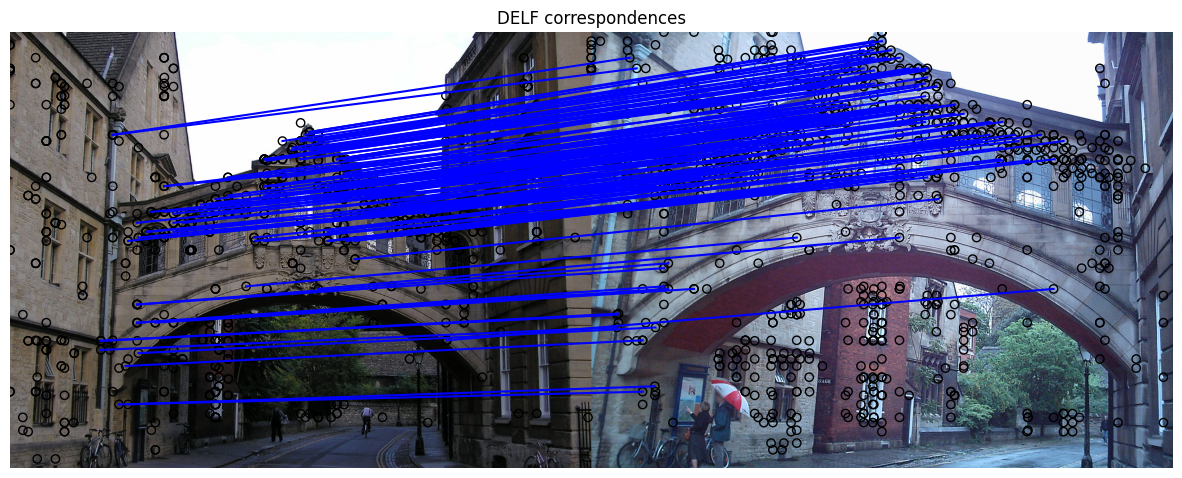

In [22]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function


# cmd_args = None


# def main():
  # Read features.
locations_1, _, descriptors_1, _, _ = feature_io.ReadFromFile(
    features_1_path)
num_features_1 = locations_1.shape[0]
print(f"Loaded image 1's {num_features_1} features")
locations_2, _, descriptors_2, _, _ = feature_io.ReadFromFile(
    features_2_path)
num_features_2 = locations_2.shape[0]
print(f"Loaded image 2's {num_features_2} features")

# Find nearest-neighbor matches using a KD tree.
d1_tree = spatial.cKDTree(descriptors_1)
_, indices = d1_tree.query(
    descriptors_2, distance_upper_bound=_DISTANCE_THRESHOLD)

# Select feature locations for putative matches.
locations_2_to_use = np.array([
    locations_2[i,]
    for i in range(num_features_2)
    if indices[i] != num_features_1
])
locations_1_to_use = np.array([
    locations_1[indices[i],]
    for i in range(num_features_2)
    if indices[i] != num_features_1
])

# Perform geometric verification using RANSAC.
_, inliers = measure.ransac((locations_1_to_use, locations_2_to_use),
                            transform.AffineTransform,
                            min_samples=3,
                            residual_threshold=20,
                            max_trials=1000)

print(f'Found {sum(inliers)} inliers')
# plt.figure(figsize=(20,20))
# Visualize correspondences, and save to file.
fig, ax = plt.subplots(figsize=(15,15))
img_1 = mpimg.imread(image_1_path)
img_2 = mpimg.imread(image_2_path)
inlier_idxs = np.nonzero(inliers)[0]
feature.plot_matched_features(
    img_1,
    img_2,
    keypoints0=locations_1_to_use,
    keypoints1=locations_2_to_use,
    matches=np.column_stack((inlier_idxs, inlier_idxs)),
    ax=ax,
    matches_color='b'
)
ax.axis('off')
ax.set_title('DELF correspondences')
# plt.savefig(output_image)

plt.show()



